# ML Foundations – Assignment 1: Data Preparation

**Author:** Nikoloz Chachia  
**GitHub Repository:** https://github.com/nika140906/ML-fundamentals-2026

## Step 1 — Task Ordering

The tasks in this assignment are listed alphabetically, but the correct methodological order is different. Below is the order I will follow and the reason for each step.

| Step | Task | Why |
|------|------|-----|
| 1 | Identifying the Prediction Target | Must be done first so all decisions are made with the right objective in mind |
| 2 | Data Loading and Exploration | Raw data must be inspected before any transformation |
| 3 | Data Splitting | Must happen before any transformation to prevent data leakage |
| 4 | Managing Missing Values | Fitted on training set only, applied to all sets |
| 5 | Encoding Categorical Variables | Encoders must be fitted on training set only |
| 6 | Feature Scaling | Scalers must be fitted on training set only |
| 7 | Feature Selection | Computed on scaled training set only |
| 8 | Addressing Class Imbalance | Applied to training set only, last preprocessing step |
| 9 | Training Logistic Regression | Only after pipeline is complete |

#### Example of Incorrect Ordering

If you apply SMOTE before splitting, the synthetic samples it generates 
could end up in both the training and test sets. That means the test set 
is no longer independent, and your evaluation results will look better 
than they actually are.


## Step 2 — Identifying the Prediction Target

The target variable is **`y`** — a binary column that tells us whether 
a client subscribed to a term deposit after being contacted ('yes' or 'no').

This is the right target because the whole point of the campaign was to 
get clients to subscribe. The variable is only known after the call, 
which means it is what we are trying to predict — not something we 
already know at contact time.

### Variables that should NOT be treated as the target:

1. **`duration`** — This is how long the phone call lasted. It sounds 
useful but the problem is we only know it after the call is over. 
If we used it as a feature it would leak information about the outcome, 
and it makes no sense as a target variable either.

2. **`campaign`** — This counts how many times the client was contacted 
during the campaign. It describes what we did, not what happened as a 
result, so it is not a meaningful prediction objective.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading the dataset
df = pd.read_csv('bank-additional.csv', sep=';')

# quick look at the first few rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [2]:
# Dataset structure
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nBasic statistics:")
df.describe()

Shape: (4119, 21)

Data types:
 age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Basic statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Step 3 — Data Loading and Exploration

The dataset contains 4119 rows and 21 columns. The variables are a mix 
of numerical (int64, float64) and categorical (object) types.

Numerical variables: age, duration, campaign, pdays, previous, 
emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

Categorical variables: job, marital, education, default, housing, 
loan, contact, month, day_of_week, poutcome, y

In [3]:
# Target variable distribution
print("Target variable distribution:")
print(df['y'].value_counts())
print("\nPercentage:")
print(df['y'].value_counts(normalize=True).round(3) * 100)

Target variable distribution:
y
no     3668
yes     451
Name: count, dtype: int64

Percentage:
y
no     89.1
yes    10.9
Name: proportion, dtype: float64


The target variable is heavily imbalanced — 89.1% of clients did not 
subscribe and only 10.9% did. This means a model that always predicts 
"no" would be 89% accurate, which is misleading. We will need to address 
this imbalance later using resampling on the training set only.

In [4]:
# check for explicit missing values (NaN)
print("Explicit missing values (NaN):")
print(df.isnull().sum())

# check for implicit missing values ('unknown' string)
print("\nImplicit missing values ('unknown'):")
for col in df.select_dtypes(include='str').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        print(f"  {col}: {count} ({round(count/len(df)*100, 1)}%)")

Explicit missing values (NaN):
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Implicit missing values ('unknown'):
  job: 39 (0.9%)
  marital: 11 (0.3%)
  education: 167 (4.1%)
  default: 803 (19.5%)
  housing: 105 (2.5%)
  loan: 105 (2.5%)


In [5]:
# pdays = 999 means the client was never previously contacted
# this is a sentinel value, not a real number of days
print("pdays value of 999 (never contacted):", (df['pdays'] == 999).sum())
print("pdays other values:", (df['pdays'] != 999).sum())

pdays value of 999 (never contacted): 3959
pdays other values: 160


The pdays column uses 999 as a sentinel value meaning the client was 
never previously contacted — not that they were contacted 999 days ago. 
We will create a binary flag for this in feature engineering.

There are no explicit missing values (NaN) in the dataset. However, 
several categorical columns contain the value 'unknown' which represents 
implicit missing values — data that was not collected or not available.

The most affected columns are:
- default: 803 unknown values (19.5% of rows)
- education: 167 unknown values
- housing and loan: 105 each
- job: 39 unknown values
- marital: 11 unknown values

We will handle these in Step 5 (Managing Missing Values) after splitting 
the data, to avoid any leakage into the validation and test sets.

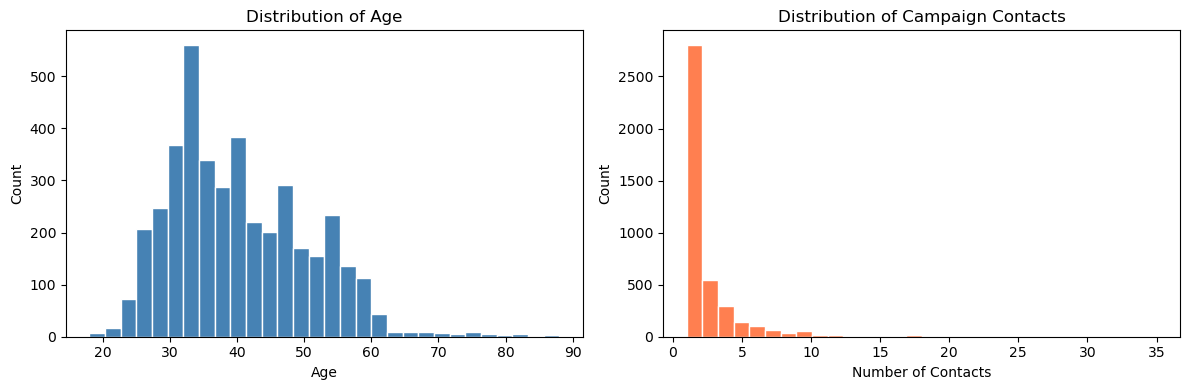

In [6]:
# Visualize two numerical variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Campaign distribution
axes[1].hist(df['campaign'], bins=30, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Campaign Contacts')
axes[1].set_xlabel('Number of Contacts')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

The age distribution is roughly bell-shaped, with most clients between 
25 and 50 years old. The campaign variable is heavily right-skewed — 
most clients were contacted only once or twice, but a small number were 
contacted up to 35 times. This extreme skewness in campaign will need 
to be considered during feature scaling.

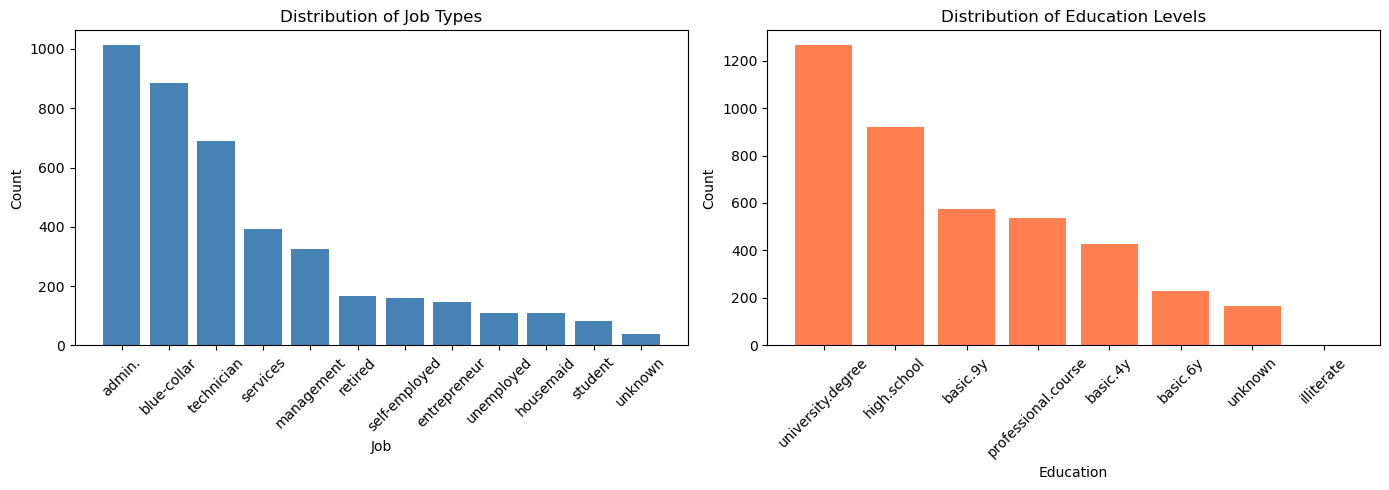

In [7]:
# Visualize two categorical variables
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Job distribution
job_counts = df['job'].value_counts()
axes[0].bar(job_counts.index, job_counts.values, color='steelblue')
axes[0].set_title('Distribution of Job Types')
axes[0].set_xlabel('Job')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Education distribution
edu_counts = df['education'].value_counts()
axes[1].bar(edu_counts.index, edu_counts.values, color='coral')
axes[1].set_title('Distribution of Education Levels')
axes[1].set_xlabel('Education')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

The most common job types are admin, blue-collar and technician. 
The education plot shows that most clients have a university degree 
or high school education. We can also clearly see the 'unknown' 
category in both plots, confirming the implicit missing values 
we identified earlier.

### Variable Requiring Special Consideration

**`duration`** — This variable records how long the phone call lasted. 
It is strongly correlated with the outcome (longer calls tend to result 
in subscriptions) but it is only known after the call ends. This means 
it cannot be used as a feature at prediction time — using it would 
cause data leakage. We will remove it from the feature set before 
training the model.

## Step 4 — Data Splitting

The first thing we need to do before any preprocessing is split the 
data into three sets:
- Training set (70%) — this is what we use to fit everything
- Validation set (15%) — used to check how things are going during development
- Test set (15%) — only touched at the very end

The reason we split first is to avoid data leakage. If we scaled or 
imputed the data before splitting, the scaler would have already seen 
the test data — which means our final evaluation would be meaningless.

We use stratified splitting because the classes are imbalanced (89% no, 
11% yes). Without stratification, we might end up with a split where 
one set has very few "yes" examples.


In [8]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df.drop(columns=['y', 'duration'])
y = df['y']

# First split: training (70%) and temporary (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (2883, 19)
Validation set: (618, 19)
Test set: (618, 19)


Split looks good — 2883 for training, 618 each for validation and test. 
I dropped duration here since we established earlier that it leaks 
information about the outcome. Used stratify to make sure the class 
imbalance (89/11 split) carries over into all three sets, otherwise 
we might get unlucky and have barely any "yes" cases in one of them.


## Step 5 — Managing Missing Values

There are no NaN values in this dataset, but we identified earlier 
that several columns contain 'unknown' as an implicit missing value. 
These need to be handled before we can encode the categorical variables.

We have two options:
- Replace 'unknown' with the most frequent value (mode imputation)
- Keep 'unknown' as its own category

Since 'default' has 803 unknowns (about 19% of the data), dropping 
those rows would lose too much data. We will use mode imputation for 
columns with few unknowns, and treat 'unknown' as a separate category 
for default since it is so common it might carry its own signal.

Importantly, we fit the imputer only on the training set and apply 
it to validation and test — to avoid any leakage.

In [9]:
# Columns with 'unknown' to impute with mode (low count)
cols_to_impute = ['job', 'marital', 'education', 'housing', 'loan']

# Fit mode on training set only
modes = X_train[cols_to_impute].mode().iloc[0]

# Apply to all three sets
X_train[cols_to_impute] = X_train[cols_to_impute].replace('unknown', modes)
X_val[cols_to_impute] = X_val[cols_to_impute].replace('unknown', modes)
X_test[cols_to_impute] = X_test[cols_to_impute].replace('unknown', modes)

# Keep 'unknown' as a category for default (too many to impute)
# Verify unknowns remaining
print("Remaining unknowns after imputation:")
for col in X_train.select_dtypes(include='str').columns:
    count = (X_train[col] == 'unknown').sum()
    if count > 0:
        print(f"{col}: {count}")
print("Done!")

Remaining unknowns after imputation:
default: 577
Done!


## Step 6 — Encoding Categorical Variables

Logistic regression can't work with text categories directly, so we 
need to convert them to numbers. We use one-hot encoding which creates 
a binary column for each category.

We use drop='first' to avoid the dummy variable trap — if we kept all 
columns, one would always be perfectly predictable from the others, 
which causes multicollinearity issues for logistic regression.

Again, we fit the encoder only on the training set and apply it to 
validation and test to prevent leakage.

In [10]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import numpy as np

# education is ordinal - there is a clear order from least to most educated
education_order = [
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree', 'unknown'
]

# all other categorical columns are nominal
nominal_cols = ['job', 'marital', 'default', 'housing', 'loan',
                'contact', 'month', 'day_of_week', 'poutcome']

# fit ordinal encoder for education on training set only
ord_encoder = OrdinalEncoder(categories=[education_order])
X_train['education'] = ord_encoder.fit_transform(X_train[['education']])
X_val['education'] = ord_encoder.transform(X_val[['education']])
X_test['education'] = ord_encoder.transform(X_test[['education']])

# fit one-hot encoder for nominal columns on training set only
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[nominal_cols])

X_train_enc = encoder.transform(X_train[nominal_cols])
X_val_enc = encoder.transform(X_val[nominal_cols])
X_test_enc = encoder.transform(X_test[nominal_cols])

enc_cols = encoder.get_feature_names_out(nominal_cols)

X_train = pd.concat([X_train.drop(columns=nominal_cols).reset_index(drop=True),
                     pd.DataFrame(X_train_enc, columns=enc_cols)], axis=1)
X_val = pd.concat([X_val.drop(columns=nominal_cols).reset_index(drop=True),
                   pd.DataFrame(X_val_enc, columns=enc_cols)], axis=1)
X_test = pd.concat([X_test.drop(columns=nominal_cols).reset_index(drop=True),
                    pd.DataFrame(X_test_enc, columns=enc_cols)], axis=1)

print("Shape after encoding:", X_train.shape)
print("\nEducation encoded values (sample):")
print(X_train['education'].value_counts().sort_index())

Shape after encoding: (2883, 42)

Education encoded values (sample):
education
0.0       1
1.0     292
2.0     155
3.0     396
4.0     661
5.0     376
6.0    1002
Name: count, dtype: int64



First thing I needed to figure out was which columns are nominal and 
which are ordinal, because that changes how we encode them.

**Ordinal** (there's a clear order):
- `education` goes from illiterate all the way up to university degree. 
It makes sense to encode this as numbers 0-6 so the model knows that 
university degree > high school > basic. Used OrdinalEncoder for this.

**Nominal** (no meaningful order):
- everything else: job, marital, default, housing, loan, contact, month, 
day_of_week, poutcome. There's no reason to say admin > technician for 
example, so I used OneHotEncoder with drop='first' to turn each category 
into a binary column.

The drop='first' part is important for logistic regression. If you keep 
all dummy columns, one is always predictable from the others which causes 
multicollinearity. After encoding the dataset went from 19 to 42 columns. 
As always, encoders are fitted on training data only.

## Step 7 — Feature Scaling

I used StandardScaler which transforms each feature to mean=0 and std=1. 
Here is why this matters for logistic regression:

**Gradient descent** works much faster when features are on the same scale. 
If one feature ranges from 0 to 100000 and another from 0 to 1, the 
loss surface becomes elongated and gradient descent takes much longer 
to converge.

**Regularization** also becomes unfair without scaling. The penalty term 
treats all coefficients equally, so a feature with large raw values gets 
penalised more heavily just because of its scale, not because it is less 
important.

**Coefficient comparability** -- after scaling we can actually compare 
coefficients and say which features have more influence on the prediction. 
Without scaling this comparison is meaningless.

Only numerical columns are scaled. Scaler is fitted on training data only.

In [11]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
num_cols = X_train.select_dtypes(include='number').columns.tolist()
print("Numerical columns to scale:", num_cols)

# Fit scaler on training set only
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

# Apply to all three sets
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nAfter scaling - training set stats:")
print(X_train[num_cols].describe().round(2))

Numerical columns to scale: ['age', 'education', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'marital_married', 'marital_single', 'default_unknown', 'default_yes', 'housing_yes', 'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']

After scaling - training set stats:
           age  education  campaign    pdays  previous  emp.var.rate  \
count  2883.00    2883.00   2883.00  2883.00   2883.00       2883.00   
mean     -0.00       0.00     -0.00    -0.00      0.00         -0.00   
std       1.00       1.00      1.00     1.00      1.0

Scaling worked correctly — all features now have mean of 0 and 
standard deviation of 1. Notice that the binary encoded columns 
also got scaled, which is fine for logistic regression.


## Step 8 — Feature Selection

I did feature selection in three steps:

First I checked for low variance features. If a feature barely changes 
across samples it probably does not help the model learn anything useful. 
I set the threshold at 0.01.

Then I checked for highly correlated numerical features. If two features 
are basically saying the same thing, keeping both just adds noise and can 
mess up the logistic regression coefficients. I used 0.85 as the 
correlation threshold.

Finally I used SelectKBest with the ANOVA F-test to keep the top 20 
features that are most statistically related to the target.

Everything is fitted on training data only. If I ran feature selection 
on the full dataset before splitting, the selector would have already 
seen the test data and the results would be overly optimistic.

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

# step 1: remove low variance features
var_selector = VarianceThreshold(threshold=0.01)
var_selector.fit(X_train)
X_train = pd.DataFrame(var_selector.transform(X_train), 
                       columns=X_train.columns[var_selector.get_support()])
X_val = pd.DataFrame(var_selector.transform(X_val),
                     columns=X_train.columns)
X_test = pd.DataFrame(var_selector.transform(X_test),
                      columns=X_train.columns)
print("After variance threshold:", X_train.shape)

# step 2: check correlation between numerical features
num_cols = X_train.select_dtypes(include='number').columns
corr_matrix = X_train[num_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.85)]
print("Highly correlated features removed:", high_corr)
X_train = X_train.drop(columns=high_corr)
X_val = X_val.drop(columns=high_corr)
X_test = X_test.drop(columns=high_corr)
print("After correlation filter:", X_train.shape)

# step 3: SelectKBest with ANOVA F-test
selector = SelectKBest(score_func=f_classif, k=20)
selector.fit(X_train, y_train)
X_train_sel = selector.transform(X_train)
X_val_sel = selector.transform(X_val)
X_test_sel = selector.transform(X_test)

selected_features = X_train.columns[selector.get_support()]
scores = selector.scores_[selector.get_support()]
feature_scores = pd.DataFrame({
    'Feature': selected_features,
    'Score': scores
}).sort_values('Score', ascending=False)

print("\nTop 20 selected features:")
print(feature_scores.to_string(index=False))
print("\nFinal shape:", X_train_sel.shape)

After variance threshold: (2883, 42)
Highly correlated features removed: ['euribor3m', 'nr.employed', 'poutcome_success']
After correlation filter: (2883, 39)

Top 20 selected features:
             Feature      Score
               pdays 377.453539
        emp.var.rate 254.282040
            previous 242.923095
poutcome_nonexistent 140.411735
           month_mar  72.997655
           month_sep  66.553618
   contact_telephone  49.775383
           month_dec  31.193337
           month_may  25.188966
      cons.price.idx  24.872951
         job_student  20.585609
           month_oct  20.585609
            campaign  19.054179
     default_unknown  16.561920
      marital_single  14.468567
       cons.conf.idx  14.439957
           education  10.162085
         job_retired  10.055974
     job_blue-collar   9.705286
     marital_married   6.738603

Final shape: (2883, 20)


3 features were removed due to high correlation (euribor3m, nr.employed 
and poutcome_success are all strongly correlated with other features). 
After that SelectKBest picked the top 20. Interestingly education made 
it into the top 20 which suggests the ordinal encoding was a good call. 
The dataset went from 47 features all the way down to 20.